In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [8]:
df = pd.read_csv('/content/news.csv')
df.shape

(45757, 2)

In [9]:
df.duplicated().sum()

np.int64(0)

In [10]:
df.isnull().sum()

,0
text,0
label,0


In [11]:
df.nunique()

,0
text,45757
label,2


In [12]:
df.columns


Index(['text', 'label'], dtype='object')

In [ ]:
df.index

RangeIndex(start=0, stop=45757, step=1)

In [13]:
df.label.value_counts()

,count
label,
1,22900
0,22857


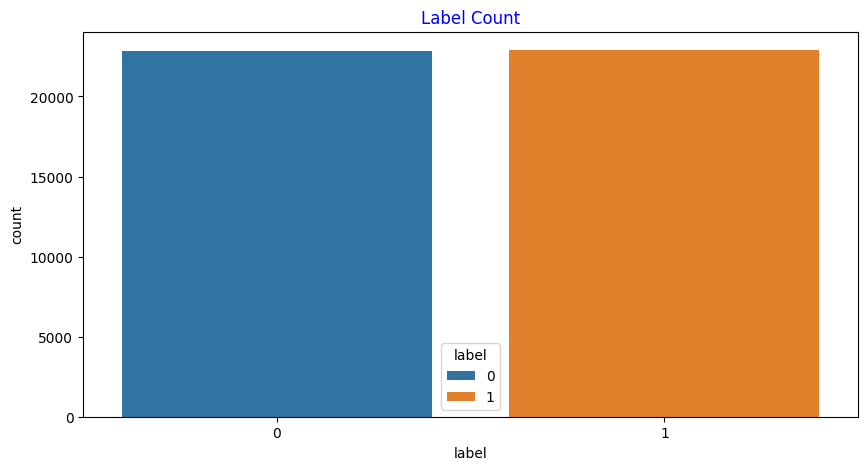

In [18]:
plt.figure(figsize=(10,5))
sns.countplot(data = df, x = 'label', hue="label")
plt.title('Label Count', color="blue")
plt.show()

In [29]:
from sklearn import preprocessing
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB

In [34]:
x=df.text
y=df.label

In [35]:
tfidf=TfidfVectorizer()
x=tfidf.fit_transform(x)

In [37]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

In [39]:
print(x_train.shape)
print(x_test.shape)
print(y_train.shape)
print(y_test.shape)

(36605, 162145)
(9152, 162145)
(36605,)
(9152,)


In [41]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

In [43]:
model=LogisticRegression()
model.fit(x_train,y_train)

LogisticRegression()

In [45]:
y_pred=model.predict(x_test)

In [47]:
print("accuracy_score:",accuracy_score(y_test, y_pred))
print("classification_report:",classification_report(y_test, y_pred))

accuracy_score: 0.9748688811188811
classification_report:               precision    recall  f1-score   support

           0       0.97      0.98      0.98      4606
           1       0.98      0.97      0.97      4546

    accuracy                           0.97      9152
   macro avg       0.97      0.97      0.97      9152
weighted avg       0.97      0.97      0.97      9152



### Taking New Input for Prediction

To predict a new headline, you need to first transform it using the same `TfidfVectorizer` that was fitted on your training data. Then, you can pass this transformed input to your trained `LogisticRegression` model.

In [ ]:
# Example: Taking a new headline as input
new_headline = "Trump is considering running for president again."

# Transform the new headline using the *already fitted* tfidf vectorizer
# It's important to use .transform() here, not .fit_transform()
new_headline_transformed = tfidf.transform([new_headline])

# Predict the label using the trained model
predicted_label = model.predict(new_headline_transformed)

# Map the numerical label back to 'Real' or 'Fake'
label_map = {0: 'Fake News', 1: 'Real News'}
predicted_category = label_map[predicted_label[0]]

print(f"The headline: '{new_headline}' is predicted as: {predicted_category}")


### Integrating into a Web Application

To integrate this into a web application (like using Flask or Streamlit), you would generally follow these steps:

1.  **Save the Trained Model and Vectorizer**: You need to save both your `LogisticRegression` model and your `TfidfVectorizer` object after training. This is crucial because you'll need them in your web application to make predictions on new input without retraining.

    ```python
    import joblib

    # Save the TF-IDF Vectorizer
    joblib.dump(tfidf, 'tfidf_vectorizer.pkl')

    # Save the Logistic Regression Model
    joblib.dump(model, 'logistic_regression_model.pkl')
    ```

2.  **Load in the Web Application**: In your web application's backend, you would load these saved objects.

    ```python
    # In your web app's script
    import joblib

    loaded_tfidf = joblib.load('tfidf_vectorizer.pkl')
    loaded_model = joblib.load('logistic_regression_model.pkl')
    ```

3.  **Create a User Interface**: Design a simple web page with an input field where users can type or paste a headline.

4.  **Process User Input**: When a user submits a headline, your web application's backend would:
    *   Receive the input text.
    *   Transform the text using the `loaded_tfidf`.
    *   Make a prediction using the `loaded_model`.
    *   Return the prediction (e.g., "Real News" or "Fake News") to the user interface.

Here's a conceptual code snippet illustrating how you might structure the prediction part in a simple Flask application (the full Flask app setup is omitted for brevity):

```python
# This is conceptual code for a web application backend
# Assume 'loaded_tfidf' and 'loaded_model' are already loaded

def predict_headline_from_web(user_input_headline):
    # Preprocess the user's input
    processed_input = loaded_tfidf.transform([user_input_headline])

    # Make prediction
    prediction = loaded_model.predict(processed_input)

    # Interpret prediction
    label_map = {0: 'Fake News', 1: 'Real News'}
    predicted_category = label_map[prediction[0]]
    return predicted_category

# Example usage within a web route (e.g., in Flask)
# @app.route('/predict', methods=['POST'])
# def predict():
#     headline = request.form['headline_text'] # Get text from web form
#     result = predict_headline_from_web(headline)
#     return render_template('result.html', prediction=result)
```

You would typically use frameworks like Flask, Django, or Streamlit (for simpler dashboards) to build the web interface and handle the backend logic.